# Automated tomography

In [1]:
from nqct.utils.QuantumSession import QuantumSession

qs = QuantumSession(api_key="PASTE_API_KEY_HERE", storage_path='temp/')
qs.list_backends();
#Copy over the desired backend from the given list
qs.select_backend('quantware_soprano_d2')

,Name,Backend ID,Qubits
0,Qiskit Aer Simulator,aer_simulator,5
1,QuantWare Soprano D2,quantware_soprano_d2,7


There is a utility to automatically generate the measurements required to perform tomography on a given state. The QASM script just has the commands required to create the state. The utility automatically adds the required headers and `qubit`/`bit` declarations and the different tomography pulses and measurement operations. The resulting measurements are stored in a bit register of size $N\cdot4^N$ for $N$ qubits, where the entries corresponding to the tomography measurements:
- The register `c` is split into groups of `N` where they are the individual qubit measurements for a given measurement
- Each group of `N` corresponds to the archetypal tomography measurements of Pauli operators. For example, with 2 qubits, the sequence would be: II, IX, IY, IZ, XI, XX, XY, XZ, YI, ..., ZY, ZZ (16 measurements in this case).

So let's take a simple example with a 2-qubit Bell state (uncomment the print statement to view the generated script):

In [2]:
from sqdtoolz.Utilities.DataDensityMatrix import DataDensityMatrix

my_script = r"""
reset q;
h q[0];
cx q[0], q[1];
"""
my_script = DataDensityMatrix.generate_tomography_qasm(my_script, num_qubits=2, qasm_include="stdgates_transmon_fixed_coupler.inc")

qs.set_qasm(my_script)
# print(my_script)

Set the mapping of the physical qubits to which to make this sample Bell state (using physical qubits on control and target being 2 and 0):

In [3]:
qs.set_qreg_physical_mapping({('q',0):2, ('q',1):0})
# qs.validate()

In [4]:
qs.set_acquisition_type('DISCRIMINATION')
qs.set_averaging_type('SingleShotCounts')
qs.set_num_shots(1024)
qs.set_shot_repeat(1)

Execute the circuit:

In [5]:
leRes = qs.run()

Plot the results, while extracting the purity and fidelity (use `plot3D` for the *cityscape* plots):

Purity=89.3%
Fidelity=91.2%


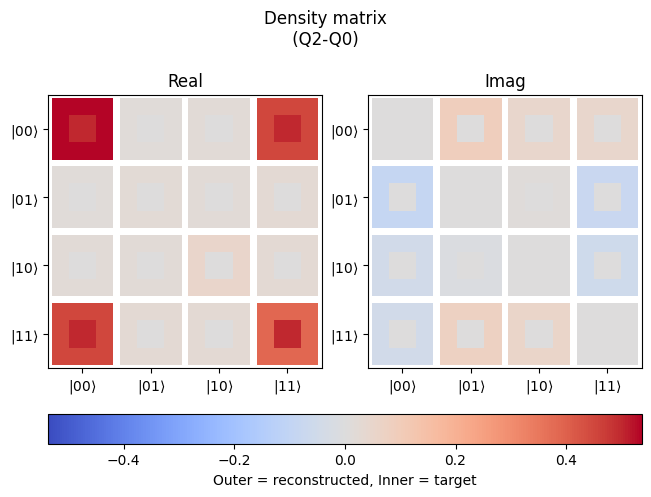

In [6]:
from sqdtoolz.Utilities.DataDensityMatrix import DataDensityMatrix
import numpy as np
shots = leRes.get_data('c')
ddm = DataDensityMatrix.fromDataViewer(leRes, use_readout_correction=True)
purity = ddm.get_purity()
fidelity = ddm.get_fidelity_pure_state(np.array([1,0,0,1])/np.sqrt(2))

ddm.plot2D(np.array([1,0,0,1])/np.sqrt(2))

print(f"Purity={purity*100:.3g}%\nFidelity={fidelity*100:.3g}%")